<h1>Train — EfficientNet-B0</h1>

Trains and evaluates EfficientNet-B0 using the tuned hyperparameters from `ARCH_HYPERPARAMS["efficientnet_b0"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["efficientnet_b0"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"EfficientNet-B0: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

EfficientNet-B0: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with EfficientNet-B0)
# ---------------------------------------------------------
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# EfficientNet's classifier is nn.Sequential(Dropout, Linear) — swap out
# just the Linear layer for our (optionally deeper) classifier head, same
# as the fc/classifier swaps used for the other architectures.
in_f = model.classifier[1].in_features
model.classifier[1] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[EfficientNet-B0] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[EfficientNet-B0] Epoch   1/100 | LR: 1.38e-03 | train loss 0.9326 acc 0.582 | val loss 0.7415 acc 0.592 *


[EfficientNet-B0] Epoch   2/100 | LR: 1.38e-03 | train loss 0.7920 acc 0.633 | val loss 0.5938 acc 0.795 *


[EfficientNet-B0] Epoch   3/100 | LR: 1.38e-03 | train loss 0.7932 acc 0.715 | val loss 0.8079 acc 0.733


[EfficientNet-B0] Epoch   4/100 | LR: 1.38e-03 | train loss 0.7262 acc 0.746 | val loss 0.6651 acc 0.707


...

[EfficientNet-B0] Epoch  25/100 | LR: 1.38e-04 | train loss 0.2119 acc 0.936 | val loss 0.4256 acc 0.842


[EfficientNet-B0] Epoch  26/100 | LR: 1.38e-04 | train loss 0.1912 acc 0.932 | val loss 0.4152 acc 0.848


[EfficientNet-B0] Epoch  27/100 | LR: 1.38e-04 | train loss 0.1534 acc 0.950 | val loss 0.4006 acc 0.853


[EfficientNet-B0] Epoch  28/100 | LR: 1.38e-04 | train loss 0.1491 acc 0.950 | val loss 0.4540 acc 0.850


[EfficientNet-B0] Epoch  29/100 | LR: 1.38e-04 | train loss 0.1495 acc 0.945 | val loss 0.4754 acc 0.842

[EfficientNet-B0] No val loss improvement for 10 epochs — stopping early at epoch 29.

[EfficientNet-B0] Restored best checkpoint (val loss = 0.3961)


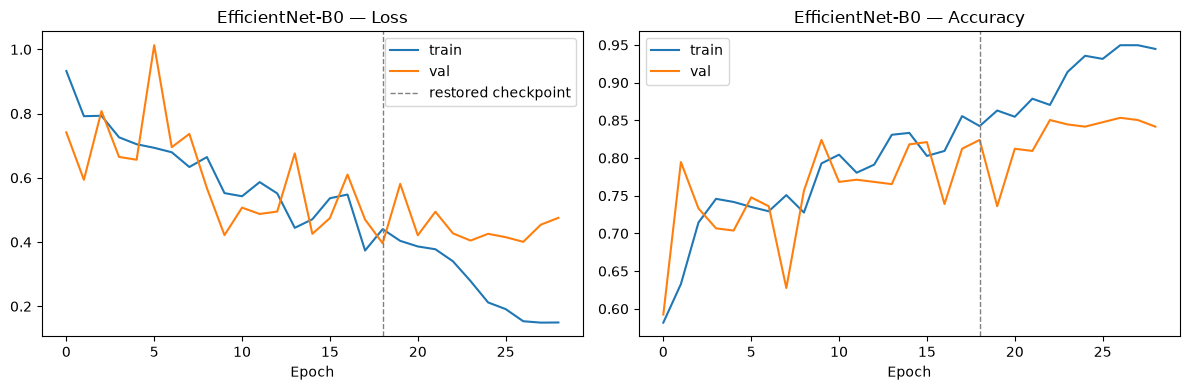

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "EfficientNet-B0", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "EfficientNet-B0")

## Evaluate on the test set

[EfficientNet-B0] Test accuracy: 0.805


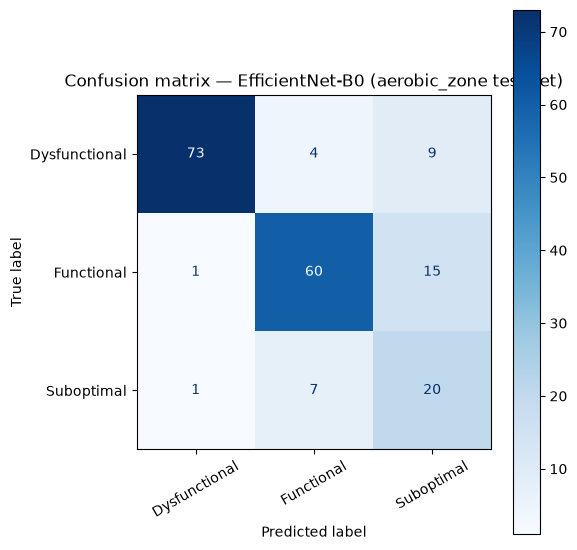

               precision    recall  f1-score   support

Dysfunctional      0.973     0.849     0.907        86
   Functional      0.845     0.789     0.816        76
   Suboptimal      0.455     0.714     0.556        28

     accuracy                          0.805       190
    macro avg      0.758     0.784     0.760       190
 weighted avg      0.846     0.805     0.819       190



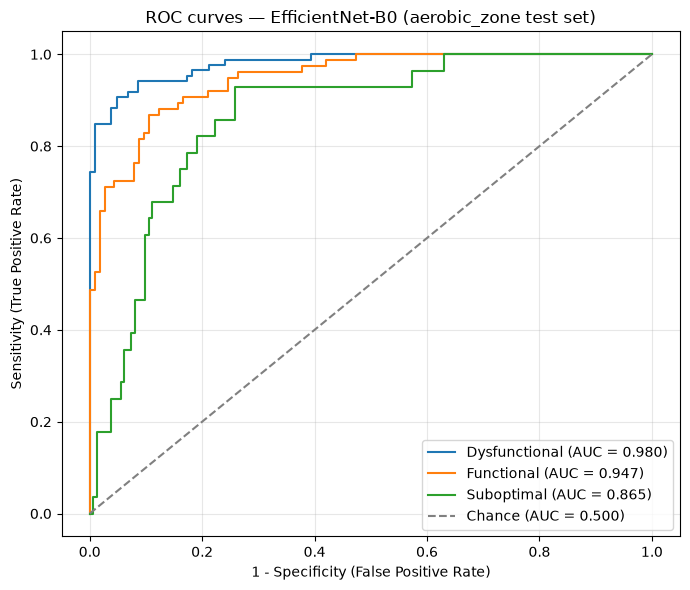

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.980
  Functional     : 0.947
  Suboptimal     : 0.865

Mean AUC (over 3/3 classes with test examples): 0.931


(np.float64(0.8052631578947368),
 {'Dysfunctional': 0.979762969588551,
  'Functional': 0.9469067405355496,
  'Suboptimal': 0.8652998236331569})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "EfficientNet-B0", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("EfficientNet-B0", "efficientnet_b0")

Saved results to ../results/aerobic_zone_aug/results_aerobic_zone_efficientnet_b0_stratified.pkl


Saved model weights to ../models/aerobic_zone_efficientnet_b0_cnn.pt
